<a href="https://colab.research.google.com/github/DiplovRawal/AI-SEM-6/blob/Worksheet/Worksheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
zip_file_path = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset"
extract_path = "/content/"

# Unzip the file silently (-q) to the specified extraction path (-d)
!unzip -q "{zip_file_path}" -d "{extract_path}"

print(f"Successfully extracted '{zip_file_path}' to '{extract_path}'.")

unzip:  cannot find or open /content/drive/MyDrive/DevanagariHandwrittenDigitDataset, /content/drive/MyDrive/DevanagariHandwrittenDigitDataset.zip or /content/drive/MyDrive/DevanagariHandwrittenDigitDataset.ZIP.
Successfully extracted '/content/drive/MyDrive/DevanagariHandwrittenDigitDataset' to '/content/'.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0
print(x_train.shape)

x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(y_test)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28)
[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [5]:
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28*28, )
model = keras.Sequential(
  [
  keras.layers.Input(shape=input_shape),
  keras.layers.Flatten(),
  keras.layers.Dense(64, activation="sigmoid"),
  keras.layers.Dense(128, activation="sigmoid"),
  keras.layers.Dense(256, activation="sigmoid"),
  keras.layers.Dense(num_classes, activation="softmax"),
  ]
)

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
  optimizer="sgd",
  loss="categorical_crossentropy",
  metrics=["accuracy"]
)

In [8]:
batch_size = 128
epochs = 20

callbacks = [
  keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
  keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]

history = model.fit(
  x_train,
  y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_split=0.2,
  callbacks=callbacks,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1145 - loss: 2.3061 - val_accuracy: 0.1060 - val_loss: 2.3017
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1172 - loss: 2.3002 - val_accuracy: 0.1330 - val_loss: 2.2997
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1211 - loss: 2.2988 - val_accuracy: 0.1060 - val_loss: 2.2999
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1228 - loss: 2.2975 - val_accuracy: 0.1060 - val_loss: 2.2974
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.1287 - loss: 2.2957 - val_accuracy: 0.1060 - val_loss: 2.2970
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1289 - loss: 2.2945 - val_accuracy: 0.1060 - val_loss: 2.2932
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1283 - loss: 2.2928 - val_accuracy: 0.1070 - val_loss: 2.2914
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1373 - loss: 2.2906 - val_accuracy: 0.

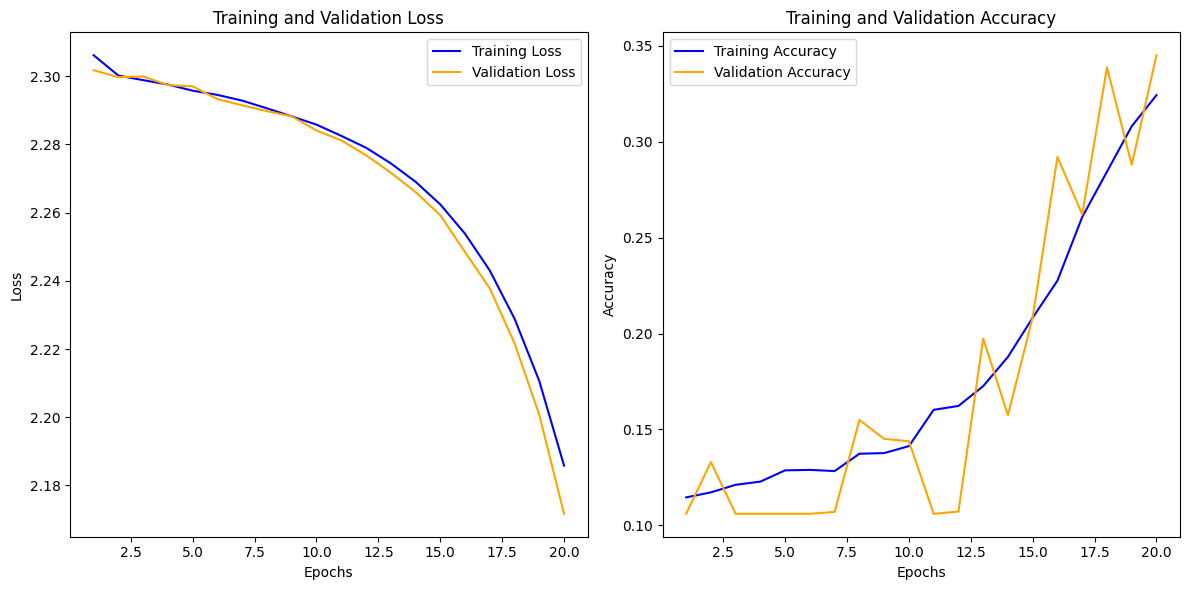

In [9]:
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
import os
import numpy as np
from PIL import Image

def one_hot_encode(labels, num_classes):
    return np.eye(num_classes)[labels]

In [11]:
def load_dataset(folder_path, img_size=(28, 28)):
    images = []
    labels = []
    class_names = []

    # Sort classes to keep label order consistent
    classes = sorted(os.listdir(folder_path))

    for label, class_name in enumerate(classes):
        class_path = os.path.join(folder_path, class_name)

        if os.path.isdir(class_path):
            class_names.append(class_name)

            for file in os.listdir(class_path):
                img_path = os.path.join(class_path, file)

                try:
                    # Load image using PIL
                    img = Image.open(img_path).convert("RGB")

                    # Resize image
                    img = img.resize(img_size)

                    # Convert to numpy & normalize (0–1)
                    img_array = np.array(img) / 255.0

                    images.append(img_array)
                    labels.append(label)

                except:
                    continue  # skip bad files

    return np.array(images), np.array(labels), class_names

In [ ]:
train_path = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train"

X_train, y_train, class_names = load_dataset(train_path)

# One-hot encode labels
y_train_encoded = one_hot_encode(y_train, len(class_names))

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_encoded.shape)
print("Classes:", class_names)

In [ ]:
test_path = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train"

X_test, y_test, _ = load_dataset(test_path)

y_test_encoded = one_hot_encode(y_test, len(class_names))

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test_encoded.shape)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(28, 28, 3)),

    Dense(64, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),

    Dense(10, activation='softmax')
])

model.summary()

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # because of one-hot encoding
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

history = model.fit(
    X_train,
    y_train_encoded,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_encoded)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [ ]:
model.save("final_model.h5")

In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model.h5")

In [ ]:
loss, acc = loaded_model.evaluate(X_test, y_test_encoded)

print("Loaded Model Accuracy:", acc)

In [ ]:
predictions = loaded_model.predict(X_test)

In [ ]:
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_encoded, axis=1)

In [ ]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(X_test[i])
    plt.title(f"Pred: {predicted_labels[i]}, Actual: {true_labels[i]}")
    plt.axis("off")
    plt.show()